In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Add the missing module to path
sys.path.append('.')

from missing import fill_missing

# Load the raw consumption data
consumption_path = '../../../data/paraguay/electricity-consumption-raw.csv'
df_consumption = pd.read_csv(consumption_path)

print(f"Loaded {len(df_consumption)} records")
print(f"Missing values: {df_consumption['consumption'].isna().sum()}")
print(f"Feeders: {df_consumption['feeder'].nunique()}")

Loaded 1899312 records
Missing values: 50365
Feeders: 55


In [2]:
# Fill missing values using the function
df_consumption_filled = fill_missing(df_consumption)

Found 10 highly correlated feeder pairs (correlation > 0.8)
Feeder A1: Filled 1031 values using temporal interpolation
Feeder A2: Filled 385 values using temporal interpolation
Feeder B1: Filled 428 values using temporal interpolation
Feeder B2: Filled 769 values using temporal interpolation
Feeder B3: Filled 369 values using temporal interpolation
Feeder B4: Filled 366 values using temporal interpolation
Feeder B5: Filled 462 values using temporal interpolation
Feeder B6: Filled 410 values using temporal interpolation
Feeder C1: Filled 937 values using temporal interpolation
Feeder C2: Filled 1283 values using temporal interpolation
Feeder D1: Filled 2001 values using temporal interpolation
Feeder D2: Filled 1359 values using temporal interpolation
Feeder D3: Filled 1287 values using temporal interpolation
Feeder E1: Filled 120 values using temporal interpolation
Feeder E2: Filled 38 values using temporal interpolation
Feeder E3: Filled 280 values using temporal interpolation
Feeder E

In [3]:
# Extract E5 feeder data before and after filling
df_consumption['datetime'] = pd.to_datetime(df_consumption['datetime'])
df_E5_before = df_consumption[df_consumption['feeder'] == 'E5'].copy()
df_E5_before = df_E5_before.set_index('datetime').sort_index()

df_consumption_filled['datetime'] = pd.to_datetime(df_consumption_filled['datetime'])
df_E5_after = df_consumption_filled[df_consumption_filled['feeder'] == 'E5'].copy()
df_E5_after = df_E5_after.set_index('datetime').sort_index()

# Resample to daily averages for better visualization
df_E5_before_daily = df_E5_before.resample('D')['consumption'].mean()
df_E5_after_daily = df_E5_after.resample('D')['consumption'].mean()

print(f"E5 Before - Missing values: {df_E5_before['consumption'].isna().sum()}")
print(f"E5 After - Missing values: {df_E5_after['consumption'].isna().sum()}")

E5 Before - Missing values: 547
E5 After - Missing values: 0


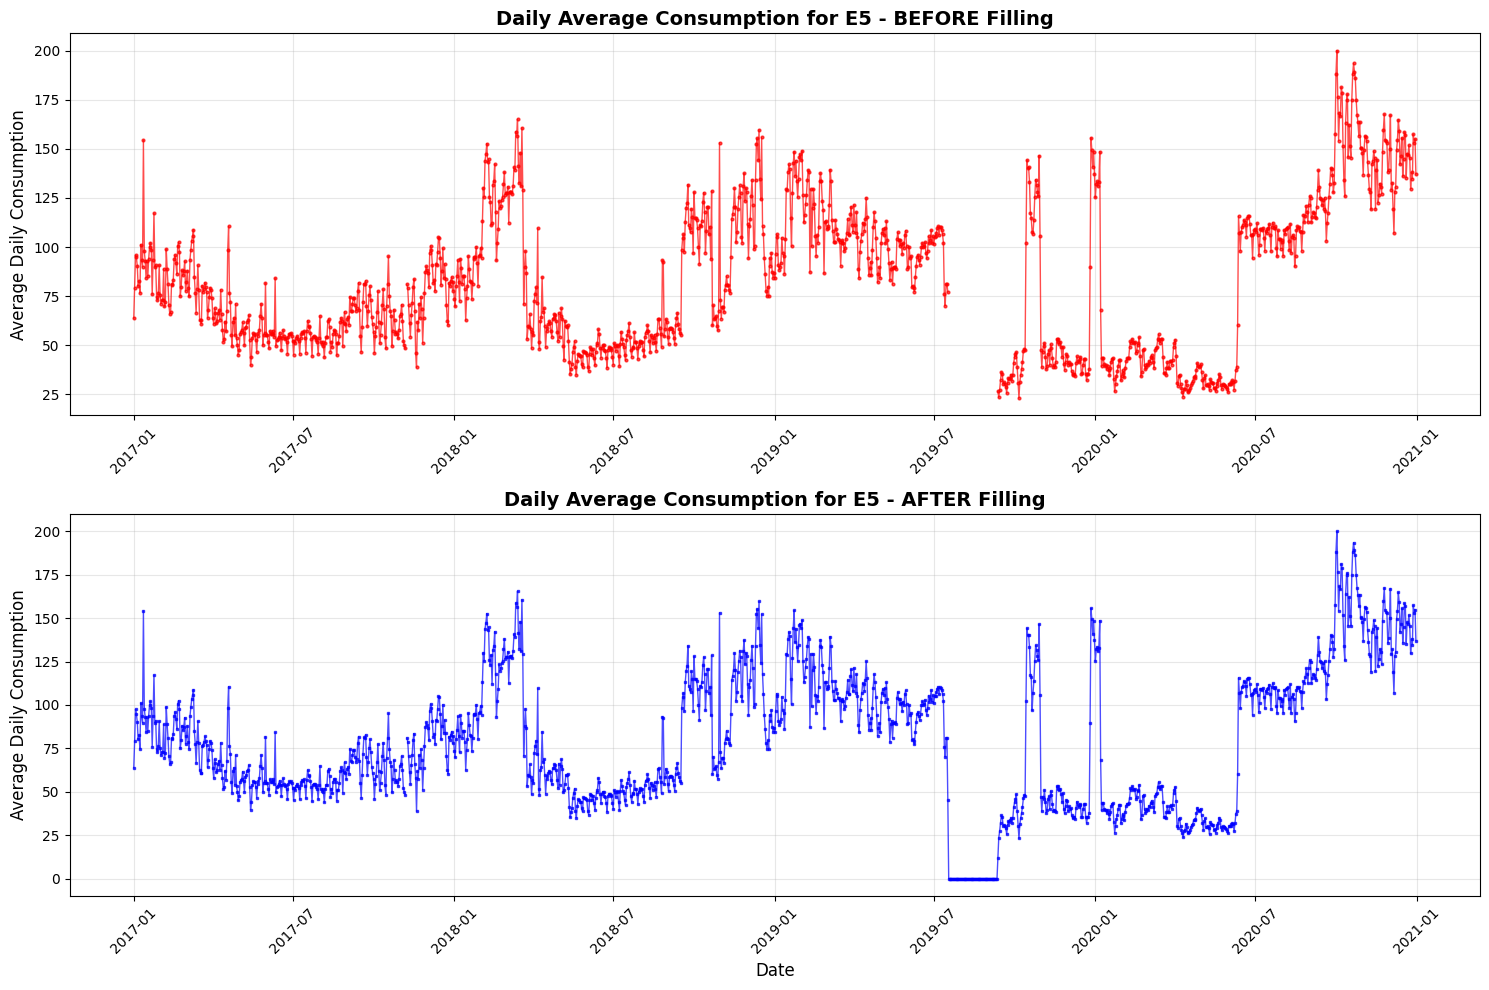


Statistics for E5:
BEFORE - Mean: 82.25
BEFORE - Std: 39.57
BEFORE - Missing: 547 (1.6%)

AFTER - Mean: 79.03
AFTER - Std: 41.94
AFTER - Missing: 0 (0.0%)


In [4]:
# Plot before and after comparison for E5
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Before filling
axes[0].plot(df_E5_before_daily.index, df_E5_before_daily.values, 
             marker='o', linestyle='-', markersize=2, linewidth=1, 
             color='red', alpha=0.7)
axes[0].set_title('Daily Average Consumption for E5 - BEFORE Filling', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Daily Consumption', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: After filling
axes[1].plot(df_E5_after_daily.index, df_E5_after_daily.values, 
             marker='s', linestyle='-', markersize=2, linewidth=1, 
             color='blue', alpha=0.7)
axes[1].set_title('Daily Average Consumption for E5 - AFTER Filling', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Average Daily Consumption', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print statistics
print("\nStatistics for E5:")
print("=" * 50)
print(f"BEFORE - Mean: {df_E5_before['consumption'].mean():.2f}")
print(f"BEFORE - Std: {df_E5_before['consumption'].std():.2f}")
print(f"BEFORE - Missing: {df_E5_before['consumption'].isna().sum()} ({df_E5_before['consumption'].isna().sum() / len(df_E5_before) * 100:.1f}%)")
print()
print(f"AFTER - Mean: {df_E5_after['consumption'].mean():.2f}")
print(f"AFTER - Std: {df_E5_after['consumption'].std():.2f}")
print(f"AFTER - Missing: {df_E5_after['consumption'].isna().sum()} ({df_E5_after['consumption'].isna().sum() / len(df_E5_after) * 100:.1f}%)")